In [ ]:
import pandas as pd
import glob

num_tau = 3
files = sorted(glob.glob(f"tau_{num_tau}uS/waveform_*.csv"))

dataframes = []

for f in files:
    df_read = pd.read_csv(f)
    dataframes.append(df_read["Voltage (V)"])

# combine voltages column-wise
combined = pd.concat(dataframes, axis=1)

# compute average voltage
avg_voltage = combined.mean(axis=1)

# use time from first file
time_read = pd.read_csv(files[0])["Time (s)"]

avg_df = pd.DataFrame({
    "Time (s)": time_read,
    "Voltage (V)": avg_voltage 
    # Please add STD.DEV
})


avg_df.to_csv(f"tau_{num_tau}uS/averaged_waveform.csv", index=False)


In [ ]:
import pandas as pd
import glob

num_tau = 2

files = glob.glob(f"tau_{num_tau}uS/waveform_*.csv")

dataframes = []

for i, f in enumerate(files):
    # if i 
    df_read = pd.read_csv(f)
    dataframes.append(df_read["Voltage (V)"])

# combine voltages column-wise
combined = pd.concat(dataframes, axis=1)

# compute average voltage
avg_voltage = combined.mean(axis=1)

# use time from first file
time_read = pd.read_csv(files[0])["Time (s)"]

avg_df = pd.DataFrame({
    "Time (s)": time_read,
    "Voltage (V)": avg_voltage 
    # Please add STD.DEV
})


avg_df.to_csv(f"tau_{num_tau}uS/averaged_waveform.csv", index=False)

In [7]:
import os

def list_folder_names_os(directory_path):
    """
    Returns a list of folder names (not full paths) in the specified directory.
    """
    # Use os.path.join to create the full path for the isdir check
    return [name for name in os.listdir(directory_path) 
            if os.path.isdir(os.path.join(directory_path, name))]

# Example usage:
directory_to_scan = '.' # Scans the current working directory
folders = list_folder_names_os(directory_to_scan)

# def list_files_os(directory_path):
#     files_list = []
#     # Iterate over all entries in the directory
#     for entry_name in os.listdir(directory_path):
#         # Create the full path for each entry
#         full_path = os.path.join(directory_path, entry_name)
#         # Check if the entry is a file
#         if os.path.isfile(full_path):
#             files_list.append(entry_name)
#     return files_list

def num_files(directory_path):
    length = 0
    for entry_name in os.listdir(directory_path):
        full_path = os.path.join(directory_path, entry_name)
        if os.path.isfile(full_path):
            length += 1
    return length

files = num_files(folders[0])
print(files)

200


# Averaging Waveforms

## 1

In [ ]:
import pandas as pd

import os

def list_folder_names_os(directory_path):
    """
    Returns a list of folder names (not full paths) in the specified directory.
    """
    # Use os.path.join to create the full path for the isdir check
    return [name for name in os.listdir(directory_path) 
            if os.path.isdir(os.path.join(directory_path, name))]

def num_files(directory_path):
    length = 0
    for entry_name in os.listdir(directory_path):
        full_path = os.path.join(directory_path, entry_name)
        if os.path.isfile(full_path):
            length += 1
    return length

directory_to_scan = '.' # Scans the current working directory
folders = list_folder_names_os(directory_to_scan)


for tau in folders:
    dataframe_pol = [] # polarize pulse waveform, even-numbered files
    dataframe_read = []

    num_waveform = num_files(tau)
    for i in range(0,num_waveform):
        if i % 2 != 0:
            file_name_read = f"{tau}/waveform_{i}.csv"
            df_read = pd.read_csv(file_name_read)
            dataframe_read.append(df_read["Voltage (V)"])
        else:
            file_name_pol = f"{tau}/waveform_{i}.csv"
            df_read = pd.read_csv(file_name_pol)
            dataframe_pol.append(df_read["Voltage (V)"])
        

    # combine voltages column-wise
    combined_pol = pd.concat(dataframe_pol, axis=1)
    combined_read = pd.concat(dataframe_read, axis=1)

    # compute average voltage
    avg_voltage_pol = combined_pol.mean(axis=1)
    avg_voltage_read = combined_read.mean(axis=1)

    # use time from first file
    time_read = pd.read_csv(f"{tau}/waveform_0.csv")["Time (s)"]

    avg_df_pol = pd.DataFrame({
        "Time (s)": time_read,
        "Voltage (V)": avg_voltage_pol
        # Please add STD.DEV
    })
    avg_df_read = pd.DataFrame({
        "Time (s)": time_read,
        "Voltage (V)": avg_voltage_read
        # Please add STD.DEV
    })
    avg_df_pol.to_csv(f"{tau}/averaged_waveform_pol.csv", index=False)
    avg_df_read.to_csv(f"{tau}/averaged_waveform_read.csv", index=False)

    print(f"saved to folder: {tau}")

saved to folder: tau_1078uS
saved to folder: tau_12293uS
saved to folder: tau_13uS
saved to folder: tau_154uS
saved to folder: tau_1754uS
saved to folder: tau_20000uS
saved to folder: tau_22uS
saved to folder: tau_250uS
saved to folder: tau_2855uS
saved to folder: tau_2uS
saved to folder: tau_35uS
saved to folder: tau_3uS
saved to folder: tau_407uS
saved to folder: tau_4644uS
saved to folder: tau_58uS
saved to folder: tau_5uS
saved to folder: tau_663uS
saved to folder: tau_7556uS
saved to folder: tau_8uS
saved to folder: tau_94uS


## 2 (with Std)

In [1]:
import pandas as pd
import numpy as np
import os

# --- FUNCTIONS ---
def list_folder_names(directory_path):
    return [
        name for name in os.listdir(directory_path)
        if os.path.isdir(os.path.join(directory_path, name))
    ]

def list_waveform_files(folder):
    return sorted(
        [f for f in os.listdir(folder) if f.startswith("waveform_")],
        key=lambda x: int(x.split("_")[1].split(".")[0])
    )


# --- MAIN ---
directory_to_scan = '.'
folders = list_folder_names(directory_to_scan)


for tau in folders:

    dataframe_pol = []
    dataframe_read = []

    files = list_waveform_files(tau)

    for i, file in enumerate(files):
        file_path = os.path.join(tau, file)
        df = pd.read_csv(file_path)

        if i % 2 != 0:
            dataframe_read.append(df["Voltage (V)"])
        else:
            dataframe_pol.append(df["Voltage (V)"])

    # --- COMBINE ---
    combined_pol = pd.concat(dataframe_pol, axis=1)
    combined_read = pd.concat(dataframe_read, axis=1)

    # --- MEAN ---
    avg_voltage_pol = combined_pol.mean(axis=1)
    avg_voltage_read = combined_read.mean(axis=1)

    # --- STD (THIS IS THE KEY ADDITION) ---
    std_voltage_pol = combined_pol.std(axis=1)
    std_voltage_read = combined_read.std(axis=1)

    # --- TIME ---
    time = pd.read_csv(os.path.join(tau, files[0]))["Time (s)"]

    # --- SAVE ---
    avg_df_pol = pd.DataFrame({
        "Time (s)": time,
        "Voltage (V)": avg_voltage_pol,
        "Std (V)": std_voltage_pol
    })

    avg_df_read = pd.DataFrame({
        "Time (s)": time,
        "Voltage (V)": avg_voltage_read,
        "Std (V)": std_voltage_read
    })

    avg_df_pol.to_csv(f"{tau}/averaged_waveform_pol.csv", index=False)
    avg_df_read.to_csv(f"{tau}/averaged_waveform_read.csv", index=False)

    print(f"saved to folder: {tau}")

saved to folder: tau_1078uS
saved to folder: tau_12293uS
saved to folder: tau_13uS
saved to folder: tau_154uS
saved to folder: tau_1754uS
saved to folder: tau_20000uS
saved to folder: tau_22uS
saved to folder: tau_250uS
saved to folder: tau_2855uS
saved to folder: tau_2uS
saved to folder: tau_35uS
saved to folder: tau_3uS
saved to folder: tau_407uS
saved to folder: tau_4644uS
saved to folder: tau_58uS
saved to folder: tau_5uS
saved to folder: tau_663uS
saved to folder: tau_7556uS
saved to folder: tau_8uS
saved to folder: tau_94uS


# Plot Data

## 1 (default waveform plots)

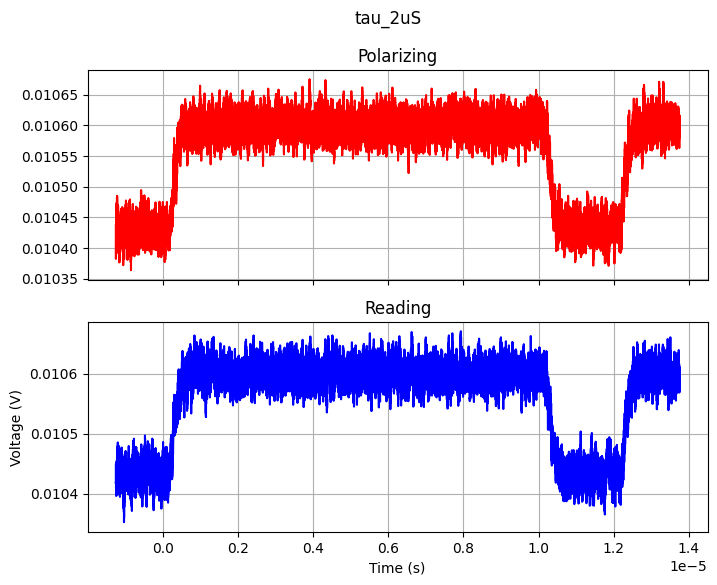

<Figure size 640x480 with 0 Axes>

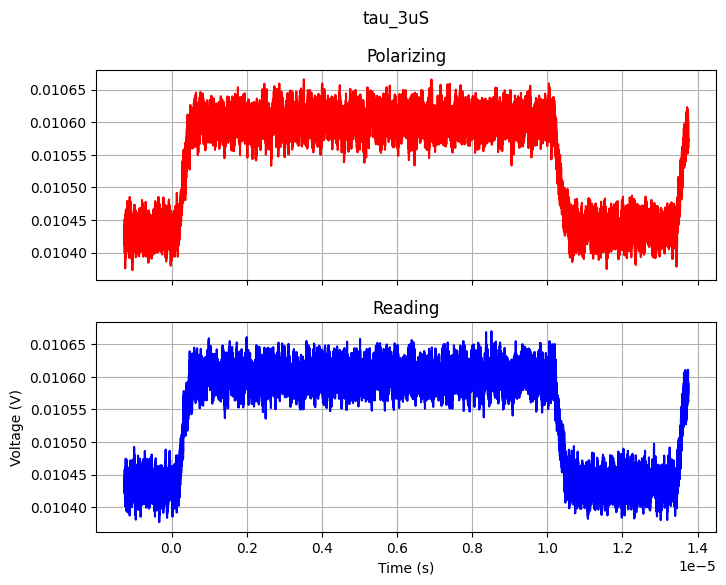

<Figure size 640x480 with 0 Axes>

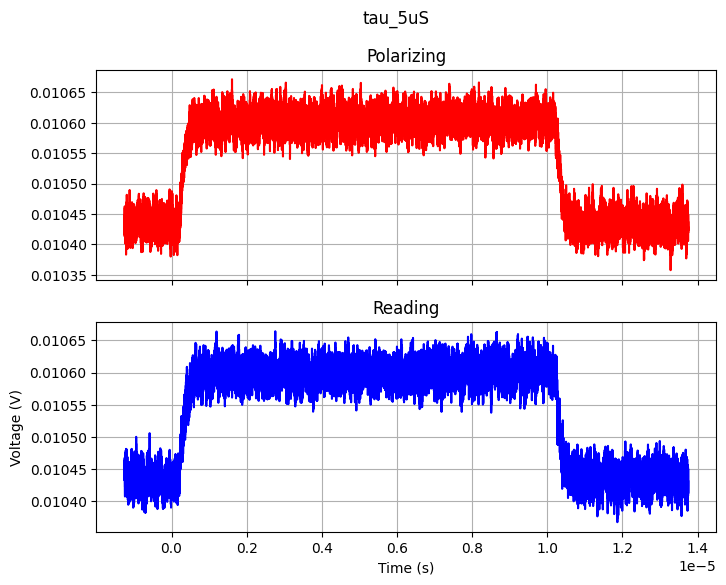

KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

In [5]:
import matplotlib.pyplot as plt
import os
from matplotlib.backends.backend_pdf import PdfPages

def list_folder_names_os(directory_path):
    """
    Returns a list of folder names (not full paths) in the specified directory.
    """
    # Use os.path.join to create the full path for the isdir check
    return [name for name in os.listdir(directory_path) 
            if os.path.isdir(os.path.join(directory_path, name))]

directory_to_scan = '.' # Scans the current working directory
folders = list_folder_names_os(directory_to_scan)
folders = sorted(folders, key=lambda x: int(x.split('_')[1].replace('uS', '')))

file_name = input("enter file name for the plots: ")

with PdfPages(f"{file_name}.pdf") as pdf:
    for tau in folders:
        data_read = np.loadtxt(f"{tau}/averaged_waveform_read.csv", delimiter=",", skiprows=1)
        data_pol = np.loadtxt(f"{tau}/averaged_waveform_pol.csv", delimiter=",", skiprows=1)

        time_read = data_read[:, 0]
        time_pol = data_pol[:, 0]
        voltage_read = data_read[:, 1]
        voltage_pol = data_pol[:, 1]
        
        # Create a figure and a 2x2 grid of axes
        fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True) #
        fig.suptitle(tau)

        # Plot data on each subplot
        axs[0].plot(time_pol, voltage_pol, 'r-')
        axs[0].set_title('Polarizing')

        axs[1].plot(time_read, voltage_read, 'b-')
        axs[1].set_title('Reading')

        plt.xlabel("Time (s)")
        plt.ylabel("Voltage (V)")
        # plt.title("Oscilloscope Waveform")
        axs[0].grid(True)
        axs[1].grid(True)


        # Adjust layout to prevent overlapping titles and labels
        # plt.tight_layout()

        # Display all plots in a single window
        plt.show()
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)  # free memory
        
print(f"Saved to {file_name}.pdf")

## 2 (highlighted reading window)

### 2a (default)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.backends.backend_pdf import PdfPages

# --- FUNCTIONS ---
def list_folder_names(directory_path):
    return [
        name for name in os.listdir(directory_path)
        if os.path.isdir(os.path.join(directory_path, name))
    ]

def extract_tau(folder_name):
    return int(folder_name.split('_')[1].replace('uS', ''))


# --- PARAMETERS (MATCH CALCULATION!) ---
polarize_pulse_width = 10e-6
readout_window = 200e-9

read_start = 15e-9                       # reading window starts at 1 microsecond
read_end   = read_start + readout_window  # reading window ends at 1.2 microseconds
t1 = polarize_pulse_width * 0.8
t2 = t1 + readout_window


# --- GET FOLDERS ---
directory_to_scan = '.'
folders = list_folder_names(directory_to_scan)
folders = sorted(folders, key=extract_tau)


file_name = input("enter file name for the plots: ")

with PdfPages(f"{file_name}.pdf") as pdf:
    for tau in folders:

        # Load data
        data_read = pd.read_csv(f"{tau}/averaged_waveform_read.csv")
        data_pol  = pd.read_csv(f"{tau}/averaged_waveform_pol.csv")

        data_read.columns = ["Time", "Voltage"]
        data_pol.columns  = ["Time", "Voltage"]

        time_read = data_read["Time"]
        voltage_read = data_read["Voltage"]

        time_pol = data_pol["Time"]
        voltage_pol = data_pol["Voltage"]

        # --- COMPUTE SIGNAL (for display) ---
        read_mask = (time_read >= read_start) & (time_read < read_end)
        ref_mask  = (time_pol >= t1) & (time_pol < t2)

        reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
        reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])

        signal = reading_int / reference_int if reference_int != 0 else np.nan

        # --- PLOTTING ---
        fig, axs = plt.subplots(2, 1, figsize=(8, 4))
        fig.suptitle(f"{tau} | Ratio = {signal:.4e}")

        # --- POLARIZING ---
        axs[0].plot(time_pol, voltage_pol)
        axs[0].grid(True)

        # --- READING ---
        axs[1].plot(time_read, voltage_read)
        axs[1].set_xlim(read_start, read_end)   # zoom into reading window
        axs[1].grid(True)

        # --- WINDOW MARKING ---
        for ax in axs:
            # Reading window
            ax.axvspan(read_start, read_end, alpha=0.35)

            # Reference window
            ax.axvspan(t1, t2, alpha=0.2)

            # Boundary lines
            ax.axvline(read_start, linestyle='--', linewidth=1)
            ax.axvline(read_end,   linestyle='--', linewidth=1)
            ax.axvline(t1, linestyle=':', linewidth=1)
            ax.axvline(t2, linestyle=':', linewidth=1)

        # --- LABELS ---
        axs[1].set_xlabel("Time (s)")
        axs[0].set_ylabel("Voltage (V)")
        axs[1].set_ylabel("Voltage (V)")

        # Annotations
        ymax_read = max(voltage_read[read_mask]) if read_mask.any() else max(voltage_read)
        # axs[1].text(read_start + readout_window * 0.1, ymax_read * 0.9, "Read", fontsize=8)

        ymax_pol = max(voltage_pol)
        # axs[0].text(t1, ymax_pol * 0.8, "Ref", fontsize=8)

        
        # Layout
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)  # free memory
        
print(f"Saved to {file_name}.pdf")

Saved to results.pdf


### 2b (modified window)

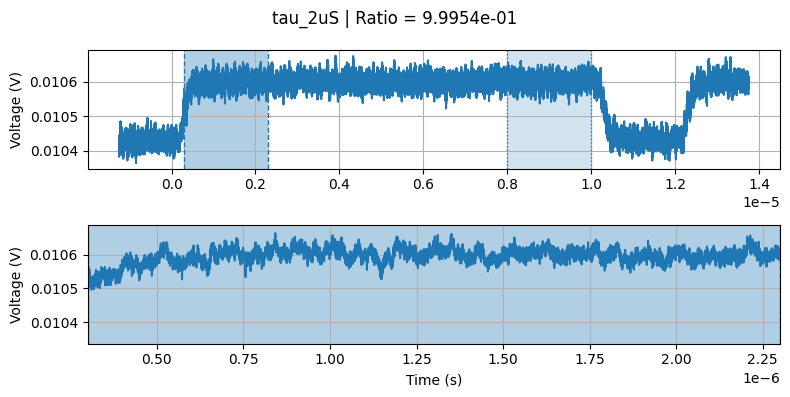

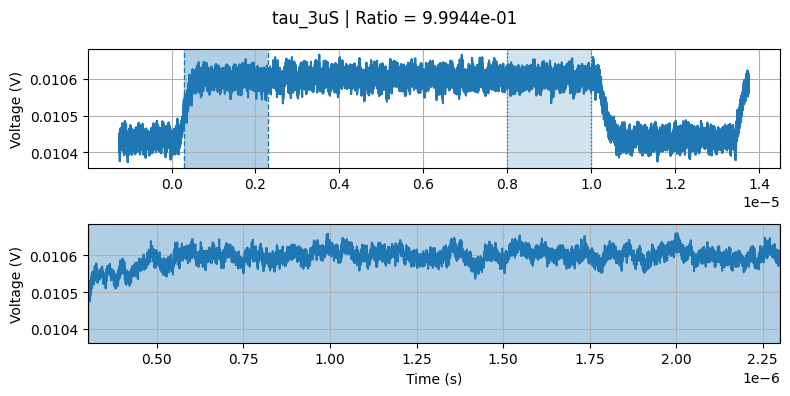

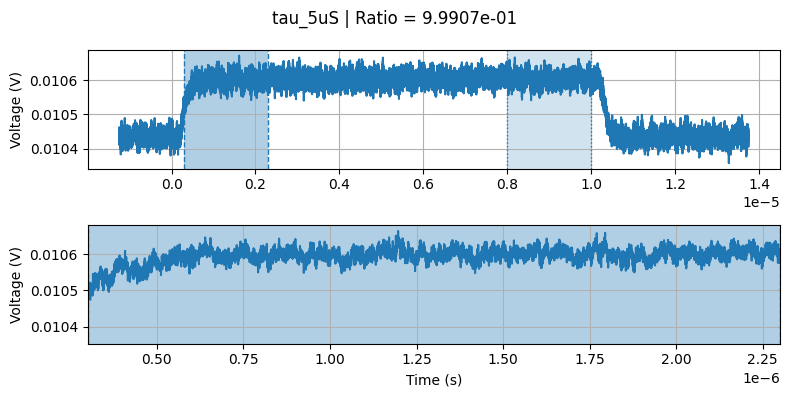

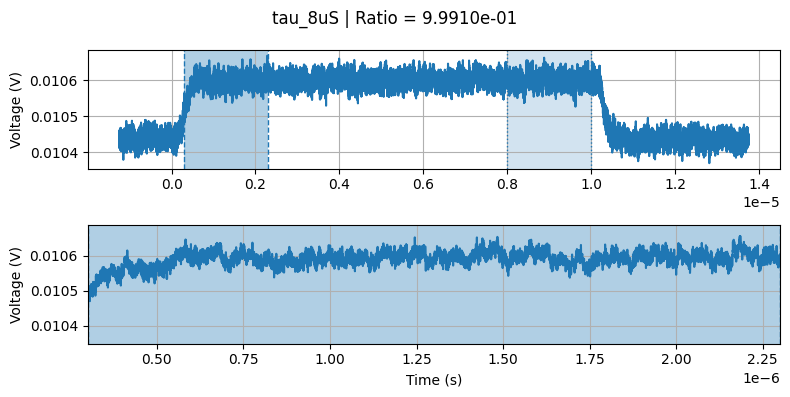

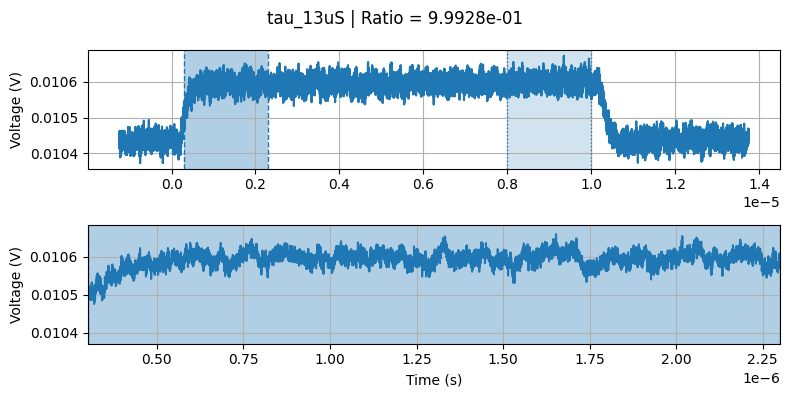

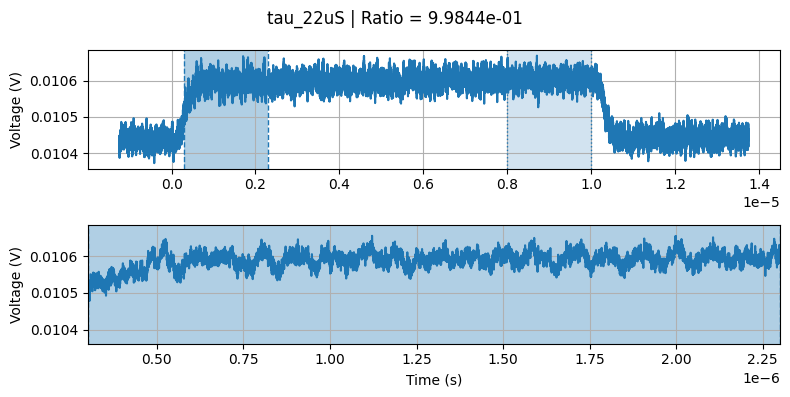

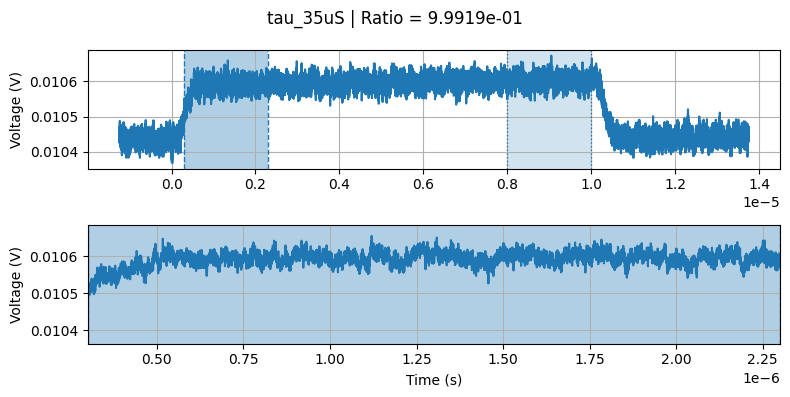

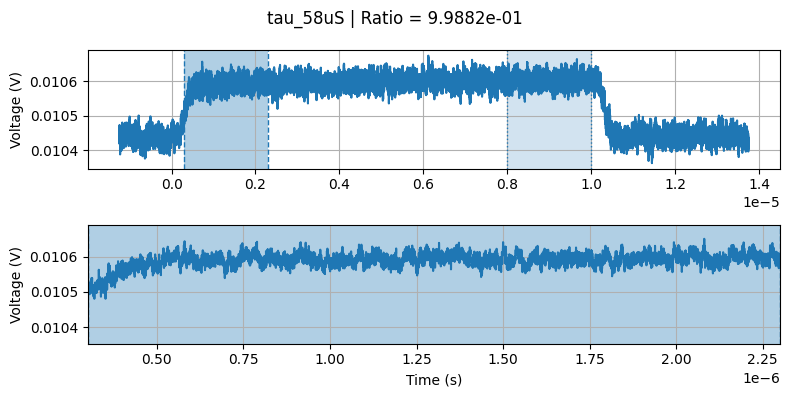

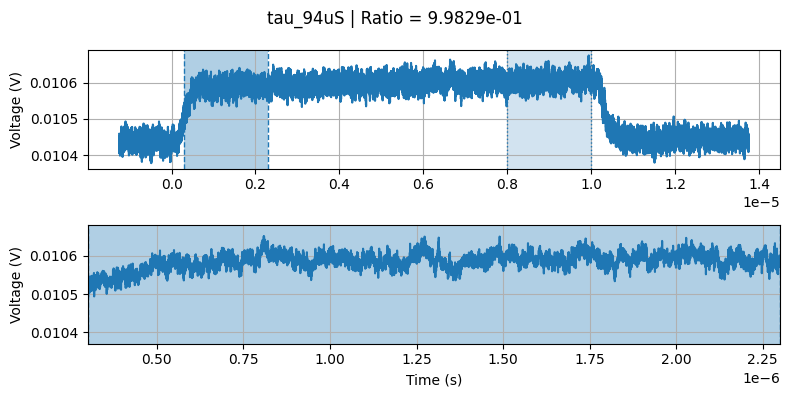

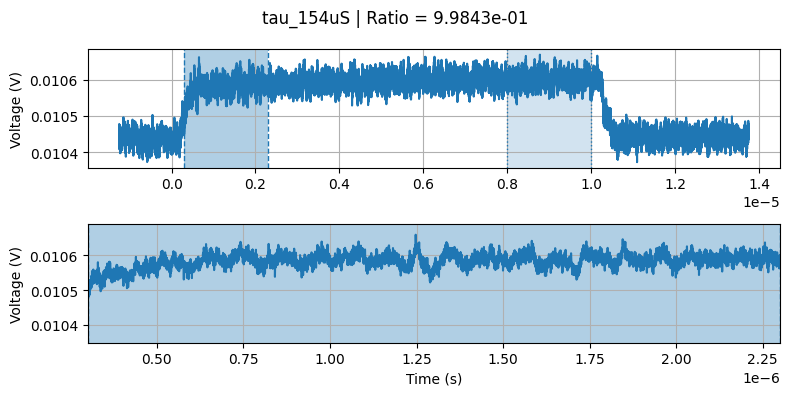

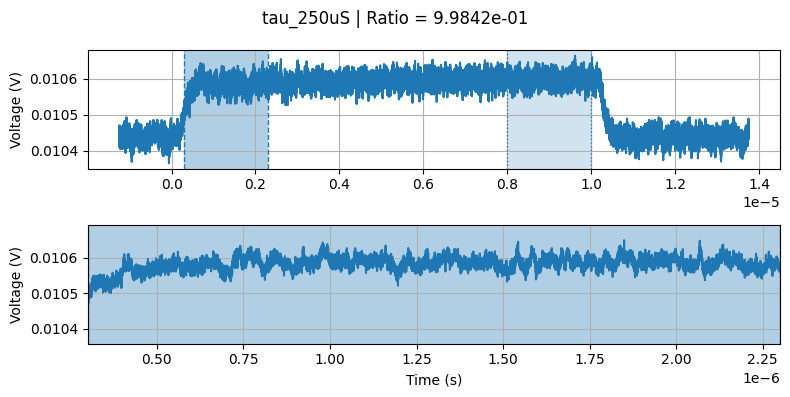

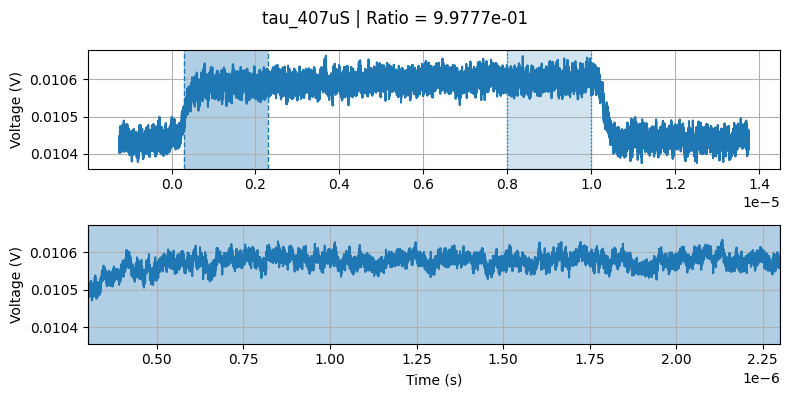

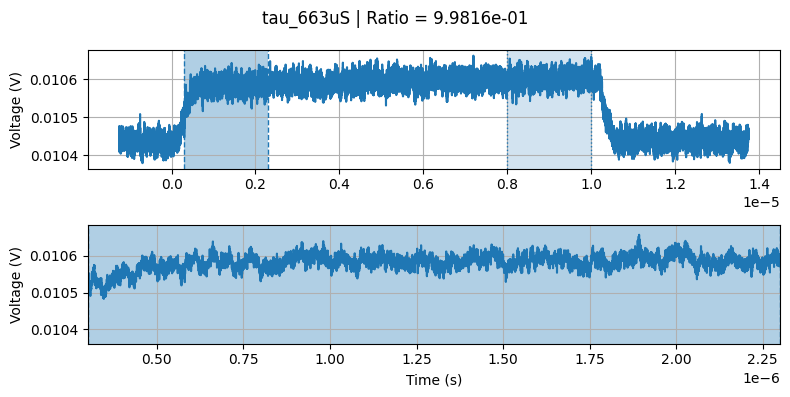

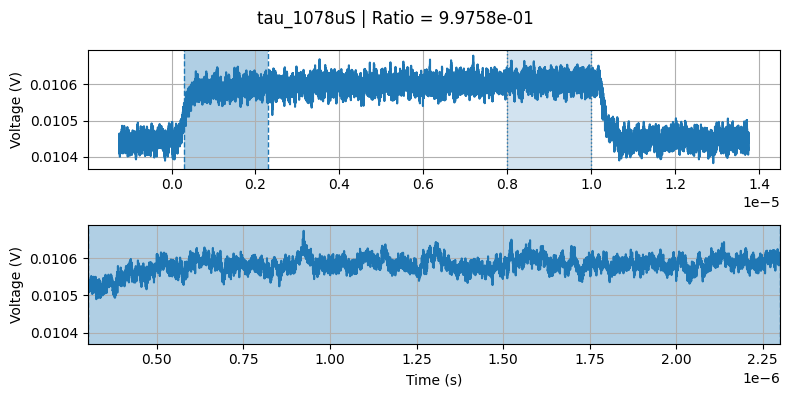

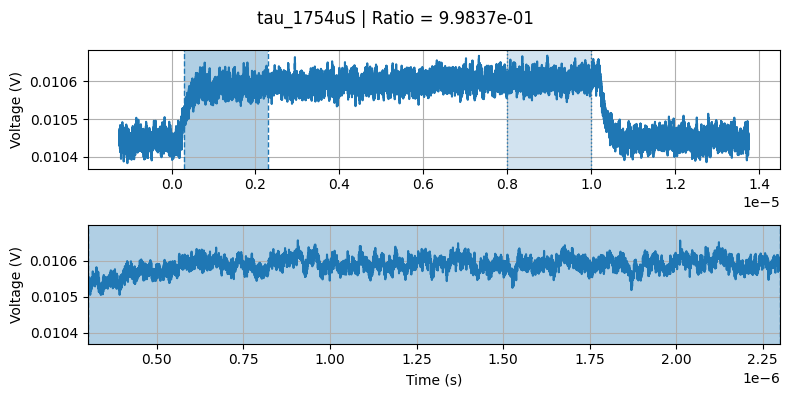

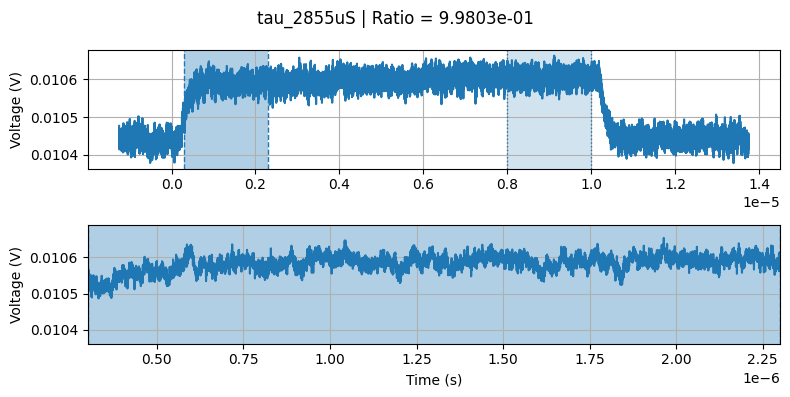

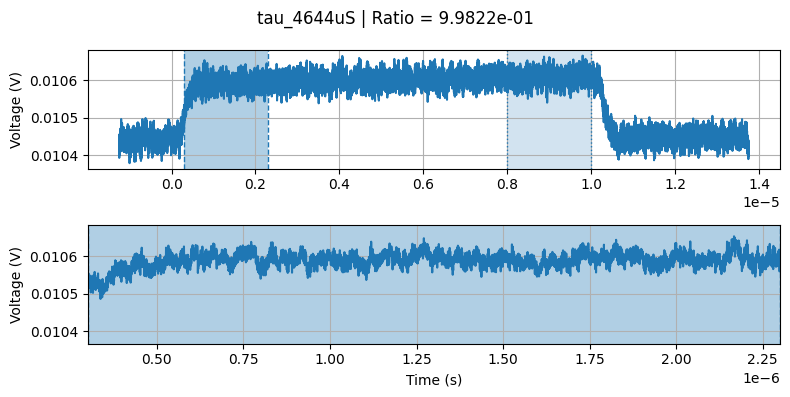

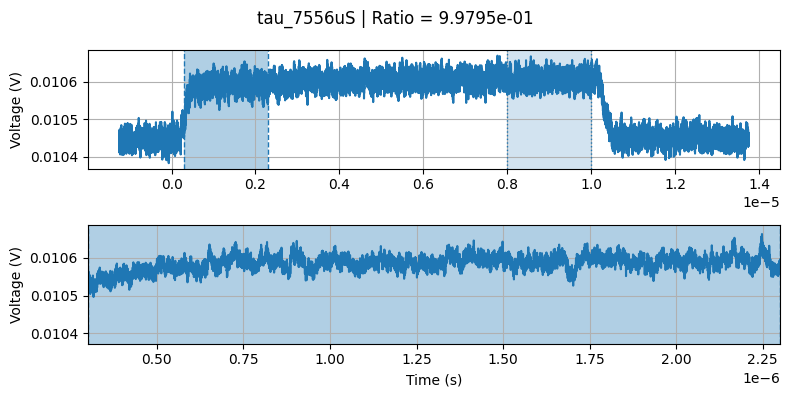

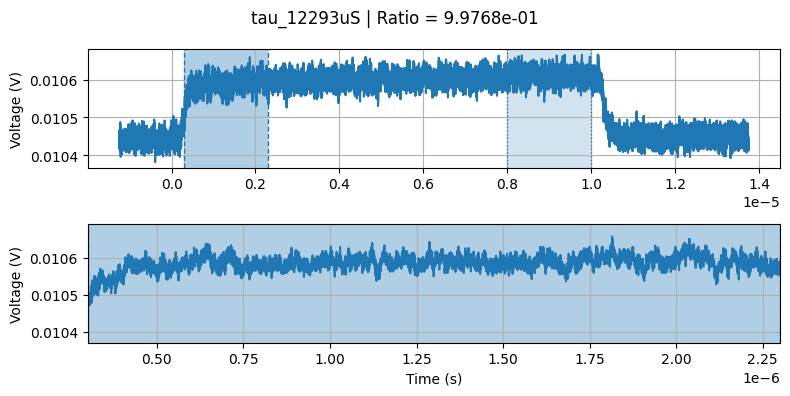

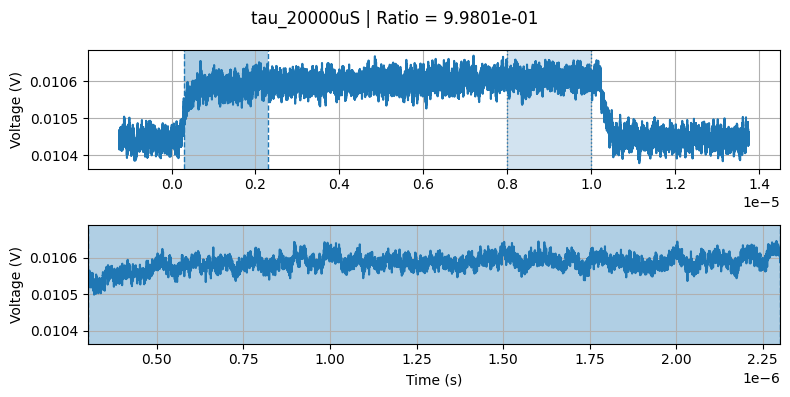

Saved to plot_start300ns_width2ms.pdf


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.backends.backend_pdf import PdfPages

# --- FUNCTIONS ---
def list_folder_names(directory_path):
    return [
        name for name in os.listdir(directory_path)
        if os.path.isdir(os.path.join(directory_path, name))
    ]

def extract_tau(folder_name):
    return int(folder_name.split('_')[1].replace('uS', ''))


# --- PARAMETERS (MATCH CALCULATION!) ---
polarize_pulse_width = 10e-6
readout_window = 2000e-9

read_start = 300e-9                       # reading window starts at 1 microsecond
read_end   = read_start + readout_window  # reading window ends at 1.2 microseconds
t1 = polarize_pulse_width * 0.8
t2 = t1 + readout_window


# --- GET FOLDERS ---
directory_to_scan = '.'
folders = list_folder_names(directory_to_scan)
folders = sorted(folders, key=extract_tau)


file_name = input("enter file name for the plots: ")

with PdfPages(f"{file_name}.pdf") as pdf:
    for tau in folders:

        # Load data
        data_read = pd.read_csv(f"{tau}/averaged_waveform_read.csv")
        data_pol  = pd.read_csv(f"{tau}/averaged_waveform_pol.csv")

        data_read.columns = ["Time", "Voltage"]
        data_pol.columns  = ["Time", "Voltage"]

        time_read = data_read["Time"]
        voltage_read = data_read["Voltage"]

        time_pol = data_pol["Time"]
        voltage_pol = data_pol["Voltage"]

        # --- COMPUTE SIGNAL (for display) ---
        read_mask = (time_read >= read_start) & (time_read < read_end)
        ref_mask  = (time_pol >= t1) & (time_pol < t2)

        reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
        reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])

        signal = reading_int / reference_int if reference_int != 0 else np.nan

        # --- PLOTTING ---
        fig, axs = plt.subplots(2, 1, figsize=(8, 4))
        fig.suptitle(f"{tau} | Ratio = {signal:.4e}")

        # --- POLARIZING ---
        axs[0].plot(time_pol, voltage_pol)
        axs[0].grid(True)

        # --- READING ---
        axs[1].plot(time_read, voltage_read)
        axs[1].set_xlim(read_start, read_end)   # zoom into reading window
        axs[1].grid(True)

        # --- WINDOW MARKING ---
        for ax in axs:
            # Reading window
            ax.axvspan(read_start, read_end, alpha=0.35)

            # Reference window
            ax.axvspan(t1, t2, alpha=0.2)

            # Boundary lines
            ax.axvline(read_start, linestyle='--', linewidth=1)
            ax.axvline(read_end,   linestyle='--', linewidth=1)
            ax.axvline(t1, linestyle=':', linewidth=1)
            ax.axvline(t2, linestyle=':', linewidth=1)

        # --- LABELS ---
        axs[1].set_xlabel("Time (s)")
        axs[0].set_ylabel("Voltage (V)")
        axs[1].set_ylabel("Voltage (V)")

        # Annotations
        ymax_read = max(voltage_read[read_mask]) if read_mask.any() else max(voltage_read)
        # axs[1].text(read_start + readout_window * 0.1, ymax_read * 0.9, "Read", fontsize=8)

        ymax_pol = max(voltage_pol)
        # axs[0].text(t1, ymax_pol * 0.8, "Ref", fontsize=8)

        # Layout
        plt.tight_layout()
        plt.show()
        # Layout
        # plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)  # free memory
print(f"Saved to {file_name}.pdf")

# !!!

## 1

In [ ]:
import numpy as np
# FIX
def list_folder_names_os(directory_path):
    """
    Returns a list of folder names (not full paths) in the specified directory.
    """
    # Use os.path.join to create the full path for the isdir check
    return [name for name in os.listdir(directory_path) 
            if os.path.isdir(os.path.join(directory_path, name))]

directory_to_scan = '.' # Scans the current working directory
tau_folders = sorted(list_folder_names_os(directory_to_scan), 
                 key=lambda x: int(x.split('_')[1].replace('uS', '')))

tau_minimum = 2
tau_maximum = 20000
n = 20
num_waveform = 200
tau = np.geomspace(tau_minimum, tau_maximum, n)

ratio_list = []

print("Dark time (us) | Ratio")

for val_t, t in enumerate(tau_folders):
    df_pol = pd.read_csv(f"{t}/averaged_waveform_pol.csv")
    df_read = pd.read_csv(f"{t}/averaged_waveform_read.csv")
    df_read.columns = ["Time","Voltage"]
    df_pol.columns = ["Time","Voltage"]

    polarize_pulse_width = 10e-6
    
    readout_window = 200e-9

    edge = 15e-9
    t0 = readout_window
    t1 = polarize_pulse_width*0.85
    t2 = t1 + readout_window

    reading = df_read[(df_read["Time"] >= 0) & (df_read["Time"] < t0)]
    # reference = df[(df["Time"] >= t1)]
    reference = df_pol[(df_pol["Time"] >= t1) & (df_pol["Time"] <t2) ]

    reading_int = np.trapz(reading["Voltage"], reading["Time"])
    reference_int = np.trapz(reference["Voltage"], reference["Time"])

    ratio = reading_int / reference_int
    ratio_list.append(ratio)
    print(f" {tau[val_t]} | {ratio:.4f}")

print(ratio_list)

import pandas as pd

# Create DataFrame
df_result = pd.DataFrame({
    "Tau (us)": tau,
    "Ratio": ratio_list
})

file_name = input("enter file name for the results: ")
# Save to Excel
df_result.to_excel(f"{file_name}_1.xlsx", index=False)

print(f"Saved to {file_name}_1.xlsx")


Dark time (us) | Ratio
 2.0 | 0.9841
 3.247553478377444 | 0.9838
 5.273301797460717 | 0.9845
 8.562664797438789 | 0.9840
 13.903855923551212 | 0.9852
 22.57675783369378 | 0.9841
 36.65961421664872 | 0.9853
 59.527028832626364 | 0.9848
 96.65860477143505 | 0.9849
 156.95199407029216 | 0.9851
 254.85499714062672 | 0.9849
 413.82761622295806 | 0.9850
 671.9636572567563 | 0.9847
 1091.118956233703 | 0.9845
 1771.733580820165 | 0.9847
 2876.8997765753265 | 0.9844
 4671.442938180243 | 0.9845
 7585.3803814644925 | 0.9844
 12316.96422132051 | 0.9849
 20000.0 | 0.9843
[0.9841150076035711, 0.9838014958942773, 0.9844772381479777, 0.9840254609275061, 0.9851721949186102, 0.9840558292916043, 0.9852889613137357, 0.9847537329125217, 0.9848666478038949, 0.985060022834849, 0.9848848465560223, 0.9849921258294715, 0.9846582655436008, 0.9845274057685192, 0.9847132153259688, 0.9844066433982057, 0.9844814785578394, 0.9844353260257465, 0.984866333477223, 0.9843150391249726]
Saved to t1_results3.xlsx


## 2

In [ ]:
import numpy as np
import os 
import pandas as pd
# FIX
def list_folder_names_os(directory_path):
    """
    Returns a list of folder names (not full paths) in the specified directory.
    """
    # Use os.path.join to create the full path for the isdir check
    return [name for name in os.listdir(directory_path) 
            if os.path.isdir(os.path.join(directory_path, name))]

directory_to_scan = '.' # Scans the current working directory
tau_folders = sorted(list_folder_names_os(directory_to_scan), 
                 key=lambda x: int(x.split('_')[1].replace('uS', '')))

tau_minimum = 2
tau_maximum = 20000
n = 20
num_waveform = 200
tau = np.geomspace(tau_minimum, tau_maximum, n)

ratio_list = []
read_list = []
pol_list = []

print("Dark time (us) | Ratio")

for val_t, t in enumerate(tau_folders):
    df_pol = pd.read_csv(f"{t}/averaged_waveform_pol.csv")
    df_read = pd.read_csv(f"{t}/averaged_waveform_read.csv")
    df_read.columns = ["Time","Voltage"]
    df_pol.columns = ["Time","Voltage"]

    polarize_pulse_width = 10e-6
    
    readout_window = 200e-9

    edge = 15e-9
    t0 = readout_window
    t1 = polarize_pulse_width*0.5
    t2 = t1 + readout_window

    reading = df_read[(df_read["Time"] >= 0) & (df_read["Time"] < t0)]
    # reference = df[(df["Time"] >= t1)]
    reference = df_pol[(df_pol["Time"] >= t1) & (df_pol["Time"] <t2) ]

    reading_int = np.trapz(reading["Voltage"], reading["Time"])
    reference_int = np.trapz(reference["Voltage"], reference["Time"])

    ratio = reading_int/reference_int
    read_list.append(reading_int)
    pol_list.append(reference_int)
    ratio_list.append(ratio)
    print(f" {tau[val_t]} | {ratio}")

print(ratio_list)

# Create DataFrame
df_result = pd.DataFrame({
    "Tau (us)": tau,
    "Ratio": ratio_list,
    "Reading" : read_list,
    "Reference" : pol_list
})

# Save to Excel
file_name = int(input("enter file number: "))
df_result.to_excel(f"t1_results{file_name}_2.xlsx", index=False)

print(f"Saved to t1_results{file_name}_2.xlsx")


Dark time (us) | Ratio
 2.0 | 0.9843825489886115
 3.247553478377444 | 0.9847506463484834
 5.273301797460717 | 0.9842430038329415
 8.562664797438789 | 0.9845679558084063
 13.903855923551212 | 0.9860340229273049
 22.57675783369378 | 0.9848226773156764
 36.65961421664872 | 0.9859852242547511
 59.527028832626364 | 0.9849043721981042
 96.65860477143505 | 0.9855513028130098
 156.95199407029216 | 0.985868438980213
 254.85499714062672 | 0.9850197119031114
 413.82761622295806 | 0.9841252189381443
 671.9636572567563 | 0.9853113466450958
 1091.118956233703 | 0.9846166362423521
 1771.733580820165 | 0.9849736994241777
 2876.8997765753265 | 0.9850202562126704
 4671.442938180243 | 0.98504791574562
 7585.3803814644925 | 0.9848208710723637
 12316.96422132051 | 0.9852747203350644
 20000.0 | 0.9855974849154019
[0.9843825489886115, 0.9847506463484834, 0.9842430038329415, 0.9845679558084063, 0.9860340229273049, 0.9848226773156764, 0.9859852242547511, 0.9849043721981042, 0.9855513028130098, 0.98586843898021

## 3

In [ ]:
import numpy as np
import os 
import pandas as pd
# FIX
def list_folder_names_os(directory_path):
    """
    Returns a list of folder names (not full paths) in the specified directory.
    """
    # Use os.path.join to create the full path for the isdir check
    return [name for name in os.listdir(directory_path) 
            if os.path.isdir(os.path.join(directory_path, name))]

directory_to_scan = '.' # Scans the current working directory
tau_folders = sorted(list_folder_names_os(directory_to_scan), 
                 key=lambda x: int(x.split('_')[1].replace('uS', '')))

tau_minimum = 2
tau_maximum = 20000
n = 20
num_waveform = 200
tau = np.geomspace(tau_minimum, tau_maximum, n)

ratio_list = []
read_list = []
pol_list = []

print("Dark time (us) | Ratio")

for val_t, t in enumerate(tau_folders):
    df_pol = pd.read_csv(f"{t}/averaged_waveform_pol.csv")
    df_read = pd.read_csv(f"{t}/averaged_waveform_read.csv")
    df_read.columns = ["Time","Voltage"]
    df_pol.columns = ["Time","Voltage"]

    polarize_pulse_width = 10e-6
    
    readout_window = 2000e-9

    read_start = 0
    t0 = read_start + readout_window
    t1 = polarize_pulse_width*0.8
    t2 = t1 + readout_window

    reading = df_read[(df_read["Time"] >= read_start) & (df_read["Time"] < t0)]
    # reference = df[(df["Time"] >= t1)]
    reference = df_pol[(df_pol["Time"] >= t1) & (df_pol["Time"] <t2) ]

    reading_int = np.trapz(reading["Voltage"], reading["Time"])
    reference_int = np.trapz(reference["Voltage"], reference["Time"])

    ratio = reading_int/reference_int
    read_list.append(reading_int)
    pol_list.append(reference_int)
    ratio_list.append(ratio)
    print(f" {tau[val_t]} | {ratio}")

print(ratio_list)

# Create DataFrame
df_result = pd.DataFrame({
    "Tau (us)": tau,
    "Ratio": ratio_list,
    "Reading" : read_list,
    "Reference" : pol_list
})

# Save to Excel
file_name = int(input("enter the file number: "))
df_result.to_excel(f"t1_results{file_name}_3.xlsx", index=False)

print(f"Saved to t1_results{file_name}_3.xlsx")


Dark time (us) | Ratio
 2.0 | 0.9974869177076724
 3.247553478377444 | 0.9973985510950153
 5.273301797460717 | 0.9969889320407325
 8.562664797438789 | 0.9970400496380148
 13.903855923551212 | 0.9973050399296562
 22.57675783369378 | 0.9964448041243198
 36.65961421664872 | 0.9972353975371975
 59.527028832626364 | 0.9968603833635016
 96.65860477143505 | 0.9964286322852713
 156.95199407029216 | 0.9965596636638335
 254.85499714062672 | 0.9965912877235524
 413.82761622295806 | 0.9958714836596204
 671.9636572567563 | 0.9962909030922239
 1091.118956233703 | 0.9957588202746073
 1771.733580820165 | 0.9964411098212097
 2876.8997765753265 | 0.9961538025144602
 4671.442938180243 | 0.9963363648226496
 7585.3803814644925 | 0.9961633723823453
 12316.96422132051 | 0.9959424609328797
 20000.0 | 0.9960979460834242
[0.9974869177076724, 0.9973985510950153, 0.9969889320407325, 0.9970400496380148, 0.9973050399296562, 0.9964448041243198, 0.9972353975371975, 0.9968603833635016, 0.9964286322852713, 0.99655966366

## 4

In [ ]:
import numpy as np
import os 
import pandas as pd

# --- FUNCTIONS ---
def list_folder_names_os(directory_path):
    return [
        name for name in os.listdir(directory_path) 
        if os.path.isdir(os.path.join(directory_path, name))
    ]

# --- GET FOLDERS ---
directory_to_scan = '.'
tau_folders = sorted(
    list_folder_names_os(directory_to_scan),
    key=lambda x: int(x.split('_')[1].replace('uS', ''))
)

# --- PARAMETERS ---
tau_minimum = 2
tau_maximum = 20000
n = 20
tau = np.geomspace(tau_minimum, tau_maximum, n)

# --- WINDOWS ---
polarize_pulse_width = 10e-6
readout_window = 1000e-9
read_start = 300e-9
t0 = read_start + readout_window
t1 = polarize_pulse_width * 0.8
t2 = t1 + readout_window

# --- STORAGE ---
ratio_list = []
read_list = []
pol_list = []

read_std_list = []
pol_std_list = []
ratio_err_list = []

print("Dark time (us) | Ratio")

# --- LOOP ---
for val_t, folder in enumerate(tau_folders):

    # --- LOAD DATA (WITH STD) ---
    df_pol = pd.read_csv(f"{folder}/averaged_waveform_pol.csv")
    df_read = pd.read_csv(f"{folder}/averaged_waveform_read.csv")

    df_read.columns = ["Time", "Voltage", "Std"]
    df_pol.columns  = ["Time", "Voltage", "Std"]

    reading = df_read[(df_read["Time"] >= read_start) & (df_read["Time"] < t0)]
    reference = df_pol[(df_pol["Time"] >= t1) & (df_pol["Time"] < t2)]

    # --- INTEGRATION ---
    reading_int = np.trapz(reading["Voltage"], reading["Time"])
    reference_int = np.trapz(reference["Voltage"], reference["Time"])

    # --- STD PROPAGATION ---
    dt_read = np.mean(np.diff(reading["Time"]))
    dt_ref  = np.mean(np.diff(reference["Time"]))

    reading_std = np.sqrt(np.sum((reading["Std"] * dt_read)**2))
    reference_std = np.sqrt(np.sum((reference["Std"] * dt_ref)**2))

    # --- RATIO ---
    ratio = reading_int / reference_int

    # --- ERROR PROPAGATION ---
    ratio_err = ratio * np.sqrt(
        (reading_std / reading_int)**2 +
        (reference_std / reference_int)**2
    )

    # --- STORE ---
    read_list.append(reading_int)
    pol_list.append(reference_int)
    ratio_list.append(ratio)

    read_std_list.append(reading_std)
    pol_std_list.append(reference_std)
    ratio_err_list.append(ratio_err)

    print(f"{tau[val_t]:8.2f} | {ratio:.4e}")

# --- SAVE ---
df_result = pd.DataFrame({
    "Tau (us)": tau,  # KEEP geomspace
    "Ratio": ratio_list,
    "Ratio Error": ratio_err_list,
    "Reading": read_list,
    "Reading STD": read_std_list,
    "Reference": pol_list,
    "Reference STD": pol_std_list
})

file_name = input("enter the file name: t1_results_..._final")
df_result.to_excel(f"t1_results_{file_name}_final.xlsx", index=False)

print(f"Saved to t1_results_{file_name}_final.xlsx")

Dark time (us) | Ratio
    2.00 | 9.9902e-01
    3.25 | 9.9874e-01
    5.27 | 9.9834e-01
    8.56 | 9.9813e-01
   13.90 | 9.9877e-01
   22.58 | 9.9768e-01
   36.66 | 9.9864e-01
   59.53 | 9.9797e-01
   96.66 | 9.9769e-01
  156.95 | 9.9767e-01
  254.85 | 9.9781e-01
  413.83 | 9.9747e-01
  671.96 | 9.9764e-01
 1091.12 | 9.9692e-01
 1771.73 | 9.9777e-01
 2876.90 | 9.9720e-01
 4671.44 | 9.9781e-01
 7585.38 | 9.9721e-01
12316.96 | 9.9695e-01
20000.00 | 9.9733e-01
Saved to t1_results_width1ms_start300ns_final.xlsx


# Curve fit

## 1

T1 = 9.5287e-05 ± 5.1e-05 s
T1 = 0.10 ± 0.05 ms
R^2 = 0.69443


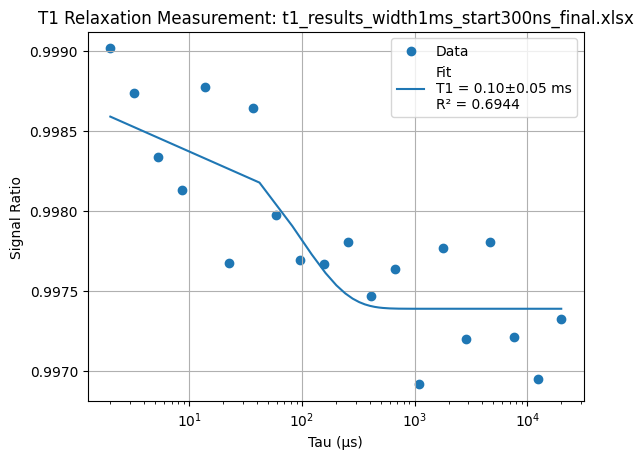

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- LOAD DATA ---
# input_file_name = input("input the file name: ")
input_file_name = "t1_results_width1ms_start300ns_final"
file_name = f"{input_file_name}.xlsx"  # change if needed
df = pd.read_excel(file_name)

tau_us = df["Tau (us)"].values
ratio = df["Ratio"].values

# Convert to seconds
t = tau_us * 1e-6

# --- MODEL ---
def exp_decay(t, I0, A, T1):
    return I0 + A * np.exp(-t / T1)


# --- INITIAL GUESS ---
p0 = [min(ratio), max(ratio)-min(ratio), 1e-3]


# --- FIT ---
params, covariance = curve_fit(exp_decay, t, ratio, p0=p0)

I0, A, T1 = params

# Standard deviations (uncertainty)
perr = np.sqrt(np.diag(covariance))
I0_err, A_err, T1_err = perr


# --- R^2 CALCULATION ---
y_fit_data = exp_decay(t, *params)

ss_res = np.sum((ratio - y_fit_data) ** 2)
ss_tot = np.sum((ratio - np.mean(ratio)) ** 2)

R2 = 1 - (ss_res / ss_tot)


# --- PRINT RESULTS ---
print(f"T1 = {T1:.4e} ± {T1_err:.1e} s")
print(f"T1 = {T1*1e3:.2f} ± {T1_err*1e3:.2f} ms")
print(f"R^2 = {R2:.5f}")


# --- GENERATE SMOOTH FIT CURVE ---
t_fit = np.linspace(min(t), max(t), 500)
y_fit = exp_decay(t_fit, *params)


# --- PLOT ---
plt.figure()

# Data
plt.scatter(tau_us, ratio, label="Data")

# Fit
plt.plot(t_fit*1e6, y_fit,
         label=f"Fit\nT1 = {T1*1e3:.2f}±{T1_err*1e3:.2f} ms\nR² = {R2:.4f}")

plt.xscale("log")
plt.xlabel("Tau (µs)")
plt.ylabel("Signal Ratio")
plt.title(f"T1 Relaxation Measurement: {file_name}")

plt.grid(True)
plt.legend()

plt.show()

## 2 (linear scale)

T1 = 9.5287e-05 ± 5.1e-05 s
T1 = 0.10 ± 0.05 ms
R^2 = 0.69443


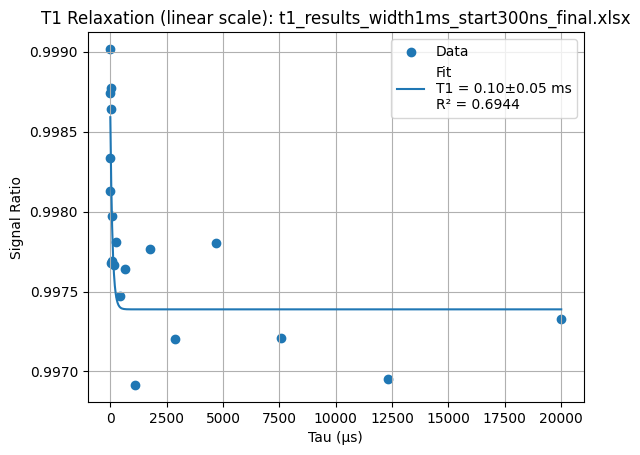

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- LOAD DATA ---
# input_file_name = input("input the file name: ")
input_file_name = "t1_results_width1ms_start300ns_final"
file_name = f"{input_file_name}.xlsx"  # change if needed
df = pd.read_excel(file_name)

tau_us = df["Tau (us)"].values
ratio = df["Ratio"].values

# Convert to seconds
t = tau_us * 1e-6

# --- MODEL ---
def exp_decay(t, I0, A, T1):
    return I0 + A * np.exp(-t / T1)


# --- INITIAL GUESS ---
p0 = [min(ratio), max(ratio)-min(ratio), 1e-3]


# --- FIT ---
params, covariance = curve_fit(exp_decay, t, ratio, p0=p0)

I0, A, T1 = params

# Standard deviations (uncertainty)
perr = np.sqrt(np.diag(covariance))
I0_err, A_err, T1_err = perr


# --- R^2 CALCULATION ---
y_fit_data = exp_decay(t, *params)

ss_res = np.sum((ratio - y_fit_data) ** 2)
ss_tot = np.sum((ratio - np.mean(ratio)) ** 2)

R2 = 1 - (ss_res / ss_tot)


# --- PRINT RESULTS ---
print(f"T1 = {T1:.4e} ± {T1_err:.1e} s")
print(f"T1 = {T1*1e3:.2f} ± {T1_err*1e3:.2f} ms")
print(f"R^2 = {R2:.5f}")


# --- GENERATE SMOOTH FIT CURVE ---
t_fit = np.linspace(min(t), max(t), 500)
y_fit = exp_decay(t_fit, *params)


# --- PLOT ---
plt.figure()

# Data
plt.scatter(tau_us, ratio, label="Data")

# Fit
plt.plot(t_fit*1e6, y_fit,
         label=f"Fit\nT1 = {T1*1e3:.2f}±{T1_err*1e3:.2f} ms\nR² = {R2:.4f}")

# plt.xscale("log")
plt.xlabel("Tau (µs)")
plt.ylabel("Signal Ratio")
plt.title(f"T1 Relaxation (linear scale): {file_name}")

plt.grid(True)
plt.legend()

plt.show()

## 3 (with error bars)


Tau (us) | Ratio | STD (Ratio Error)
    2.00 | 9.9902e-01 | 3.14e-04
    3.25 | 9.9874e-01 | 3.11e-04
    5.27 | 9.9834e-01 | 3.09e-04
    8.56 | 9.9813e-01 | 3.15e-04
   13.90 | 9.9877e-01 | 3.11e-04
   22.58 | 9.9768e-01 | 3.13e-04
   36.66 | 9.9864e-01 | 3.14e-04
   59.53 | 9.9797e-01 | 3.15e-04
   96.66 | 9.9769e-01 | 3.12e-04
  156.95 | 9.9767e-01 | 3.12e-04
  254.85 | 9.9781e-01 | 3.12e-04
  413.83 | 9.9747e-01 | 3.14e-04
  671.96 | 9.9764e-01 | 3.12e-04
 1091.12 | 9.9692e-01 | 3.13e-04
 1771.73 | 9.9777e-01 | 3.12e-04
 2876.90 | 9.9720e-01 | 3.15e-04
 4671.44 | 9.9781e-01 | 3.13e-04
 7585.38 | 9.9721e-01 | 3.13e-04
12316.96 | 9.9695e-01 | 3.13e-04
20000.00 | 9.9733e-01 | 3.12e-04


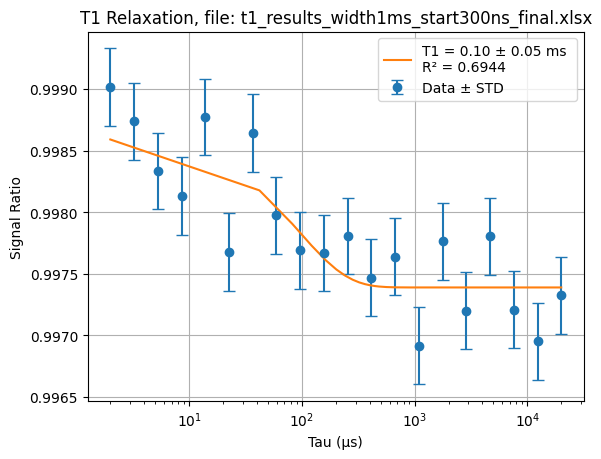

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- LOAD DATA ---
df = pd.read_excel("t1_results_width1ms_start300ns_final.xlsx")  # change file name

tau_us = df["Tau (us)"].values
ratio = df["Ratio"].values
ratio_err = df["Ratio Error"].values

t = tau_us * 1e-6


# --- MODEL ---
def exp_decay(t, I0, A, T1):
    return I0 + A * np.exp(-t / T1)


# --- WEIGHTED FIT (IMPORTANT) ---
p0 = [min(ratio), max(ratio)-min(ratio), 1e-3]

params, cov = curve_fit(
    exp_decay,
    t,
    ratio,
    p0=p0,
    sigma=ratio_err,
    absolute_sigma=True
)

I0, A, T1 = params
T1_err = np.sqrt(np.diag(cov))[2]

# --- R^2 CALCULATION ---
y_fit_data = exp_decay(t, *params)

ss_res = np.sum((ratio - y_fit_data) ** 2)
ss_tot = np.sum((ratio - np.mean(ratio)) ** 2)

R2 = 1 - (ss_res / ss_tot)

# --- PRINT EACH DATA POINT WITH STD ---
print("\nTau (us) | Ratio | STD (Ratio Error)")
for tau_val, r, err in zip(tau_us, ratio, ratio_err):
    print(f"{tau_val:8.2f} | {r:8.4e} | {err:.2e}")


# --- GENERATE FIT ---
t_fit = np.linspace(min(t), max(t), 500)
y_fit = exp_decay(t_fit, *params)


# --- PLOT ---
plt.figure()

# Error bars (this IS the STD)
plt.errorbar(
    tau_us,
    ratio,
    yerr=ratio_err,
    fmt='o',
    capsize=4,
    label="Data ± STD"
)

# Fit curve
plt.plot(
    t_fit * 1e6,
    y_fit,
    label=f"T1 = {T1*1e3:.2f} ± {T1_err*1e3:.2f} ms \nR² = {R2:.4f}"
)

# --- OPTIONAL: annotate each point ---
# for x, y, err in zip(tau_us, ratio, ratio_err):
#     plt.text(x, y, f"{err:.1e}", fontsize=7)

plt.xscale("log")
plt.xlabel("Tau (µs)")
plt.ylabel("Signal Ratio")
plt.title(f"T1 Relaxation, file: {file_name}")

plt.grid(True)
plt.legend()

plt.show()

---

In [ ]:
# FIX
list_darktime = [2, 20, 200, 2000, 20000]

ratio_list = []

print("Dark time (us) | Ratio")

for t in list_darktime:
    df_read = pd.read_csv(f"D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau {t}us/averaged_waveform.csv")
    df_read.columns = ["Time","Voltage"]

    polarize_pulse_width = 10e-6
    dark_time = t*1e-6

    t0 = polarize_pulse_width + dark_time
    t1 = t0 + 200e-9
    t2 = t1 + polarize_pulse_width - 200e-9

    reading = df_read[(df_read["Time"] >= t0) & (df_read["Time"] < t1)]
    # reference = df[(df["Time"] >= t1)]
    reference = df_read[(df_read["Time"] >= t1) & (df_read["Time"] <t2) ]

    reading_int = np.trapz(reading["Voltage"], reading["Time"])
    reference_int = np.trapz(reference["Voltage"], reference["Time"])

    ratio = reading_int / reference_int
    ratio_list.append(ratio)
    print(f" {t:13d} | {ratio:.4f}")

print(ratio_list)


Dark time (us) | Ratio
             2 | 0.0194
            20 | 0.0195
           200 | 0.0189
          2000 | 0.0153
         20000 | 0.0000
[0.019434590082047055, 0.019467104938883664, 0.01890835242982723, 0.015269299468856228, 0.0]


In [ ]:
import numpy as np
import pandas as pd

# ALTERNATIVE
list_darktime = [2, 20, 200, 2000, 20000]

ratio_list = []

print("Dark time (us) | Ratio")

for t in list_darktime:
    df_read = pd.read_csv(f"D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau {t}us/averaged_waveform.csv")
    df_read.columns = ["Time","Voltage"]

    polarize_pulse_width = 10e-6
    dark_time = t*1e-6
    readout_window = 200e-9

    t0 = polarize_pulse_width + dark_time
    t1 = t0 + readout_window
    t2 = t1 + polarize_pulse_width/2 - readout_window
    t3 = t2 + readout_window

    reading = df_read[(df_read["Time"] >= t0) & (df_read["Time"] < t1)]
    # reference = df[(df["Time"] >= t1)]
    reference = df_read[(df_read["Time"] >= t2) & (df_read["Time"] <t3) ]

    reading_int = np.trapz(reading["Voltage"], reading["Time"])
    reference_int = np.trapz(reference["Voltage"], reference["Time"])

    ratio = reading_int / reference_int
    ratio_list.append(ratio)
    print(f" {t:13d} | {ratio:.4f}")

print(ratio_list)


Dark time (us) | Ratio
             2 | 0.9517
            20 | 0.9547
           200 | 0.9358
          2000 | 0.9590
         20000 | nan
[0.9516645235016555, 0.9547010900002273, 0.9357921250507263, 0.959006821364384, nan]


C:\Users\trina\AppData\Local\Temp\ipykernel_64084\740518523.py:31: RuntimeWarning: invalid value encountered in scalar divide
  ratio = reading_int / reference_int


In [ ]:
import numpy as np
import pandas as pd

# ALTERNATIVE
list_darktime = [2, 20, 200, 2000, 20000]

ratio_list = []

print("Dark time (us) | Ratio")

for t in list_darktime:
    df_read = pd.read_csv(f"D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau {t}us/averaged_waveform.csv")
    df_read.columns = ["Time","Voltage"]

    polarize_pulse_width = 10e-6
    dark_time = t*1e-6
    readout_window = 200e-9

    t0 = polarize_pulse_width + dark_time
    t1 = t0 + readout_window
    t2 = polarize_pulse_width/2
    t3 = t2 + readout_window

    reading = df_read[(df_read["Time"] >= t0) & (df_read["Time"] < t1)]
    # reference = df[(df["Time"] >= t1)]
    reference = df_read[(df_read["Time"] >= t2) & (df_read["Time"] <t3) ]

    reading_int = np.trapz(reading["Voltage"], reading["Time"])
    reference_int = np.trapz(reference["Voltage"], reference["Time"])

    ratio = reading_int / reference_int
    ratio_list.append(ratio)
    print(f" {t:13d} | {ratio:.4f}")

print(ratio_list)


Dark time (us) | Ratio
             2 | 0.9521
            20 | 0.9561
           200 | 0.9382
          2000 | 0.7985
         20000 | nan
[0.9521136496683746, 0.9560755357917826, 0.9382404860390323, 0.7984946199937274, nan]


C:\Users\trina\AppData\Local\Temp\ipykernel_64084\76420258.py:31: RuntimeWarning: invalid value encountered in scalar divide
  ratio = reading_int / reference_int


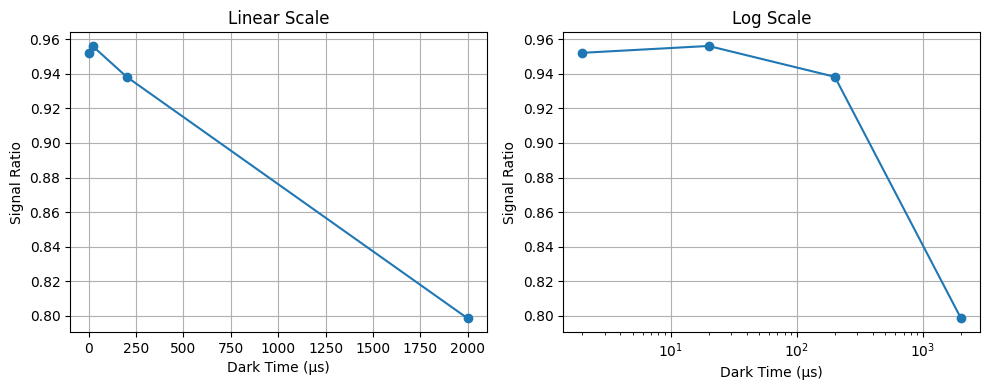

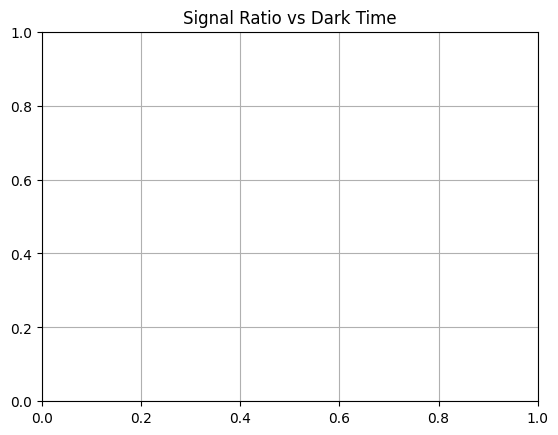

In [48]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10,4))

# Linear scale
ax[0].plot(list_darktime, ratio_list, marker='o')
ax[0].set_xlabel("Dark Time (µs)")
ax[0].set_ylabel("Signal Ratio")
ax[0].set_title("Linear Scale")
ax[0].grid(True)

# Log scale
ax[1].plot(list_darktime, ratio_list, marker='o')
ax[1].set_xscale("log")
ax[1].set_xlabel("Dark Time (µs)")
ax[1].set_ylabel("Signal Ratio")
ax[1].set_title("Log Scale")
ax[1].grid(True)

plt.tight_layout()
plt.show()
plt.title("Signal Ratio vs Dark Time")

plt.grid(True)

plt.show()

---
# Dealing with Leading Edge and Trailing Edge

In [ ]:
import numpy as np

# considering the leading edge and trailing edge
list_darktime = [2, 20, 200, 2000, 20000] # in us
list_edge = [15e-9, 15e-9, 21e-9, 301e-9, 2e-6] # in s

ratio_list = []

print("Dark time (us) | Edge time (us) | Ratio")

for edge_index, t in enumerate(list_darktime):
    df_read = pd.read_csv(f"D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau {t}us/averaged_waveform.csv")
    df_read.columns = ["Time","Voltage"]

    polarize_pulse_width = 10e-6
    dark_time = t*1e-6       
    edge = list_edge[edge_index] 

    t0 = 2*edge + polarize_pulse_width + dark_time
    t1 = t0 + edge + 200e-9
    t2 = t1 + polarize_pulse_width - 200e-9 + edge

    reading = df_read[(df_read["Time"] >= t0) & (df_read["Time"] < t1)]
    # reference = df[(df["Time"] >= t1)]
    reference = df_read[(df_read["Time"] >= t1) & (df_read["Time"] <t2) ]

    reading_int = np.trapz(reading["Voltage"], reading["Time"])
    reference_int = np.trapz(reference["Voltage"], reference["Time"])

    ratio = reading_int / reference_int
    ratio_list.append(ratio)
    print(f" {t:13d} |          {edge*1e6:.3f} | {ratio:.4f}")

# print("Dark time (us) | Ratio")


Dark time (us) | Edge time (us) | Ratio
             2 |          0.015 | 0.0208
            20 |          0.015 | 0.0209
           200 |          0.021 | 0.0212
          2000 |          0.301 | 0.0454
         20000 |          2.000 | 0.1599


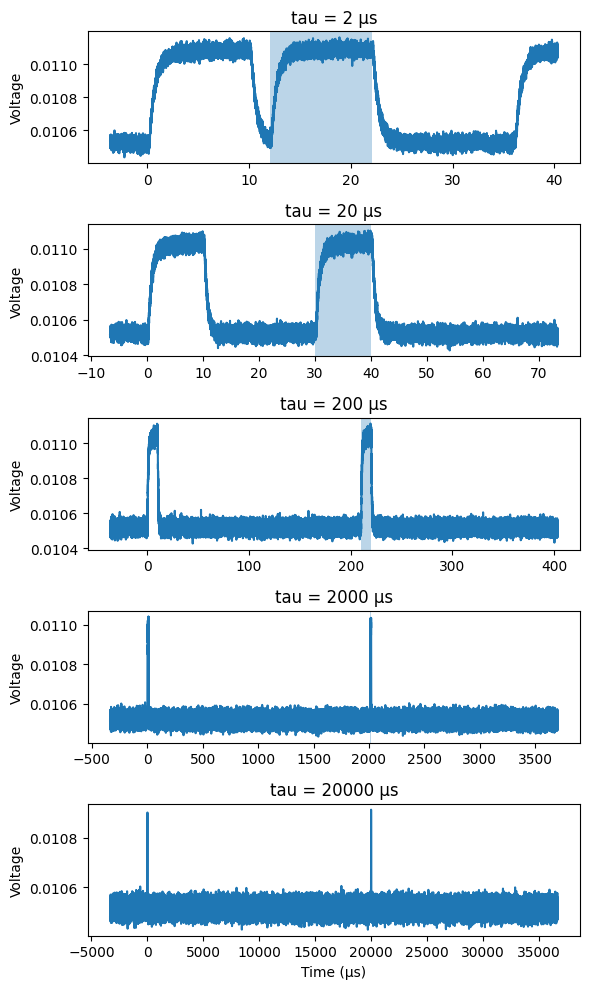

In [ ]:
fig, ax = plt.subplots(len(list_darktime), 1, figsize=(6,10))

for i, t in enumerate(list_darktime):

    df_read = pd.read_csv(f"D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau {t}us/averaged_waveform.csv")
    df_read.columns = ["Time","Voltage"]

    polarize_pulse_width = 10e-6
    dark_time = t*1e-6
    edge = list_edge[i]

    t0 = 2*edge + polarize_pulse_width + dark_time
    t1 = t0 + edge + 200e-9
    t2 = t1 + polarize_pulse_width - 200e-9 + edge

    ax[i].plot(df_read["Time"]*1e6, df_read["Voltage"])
    ax[i].axvspan(t0*1e6, t1*1e6, alpha=0.3)
    ax[i].axvspan(t1*1e6, t2*1e6, alpha=0.3)

    ax[i].set_title(f"tau = {t} µs")
    ax[i].set_ylabel("Voltage")

ax[-1].set_xlabel("Time (µs)")
plt.tight_layout()
plt.show()

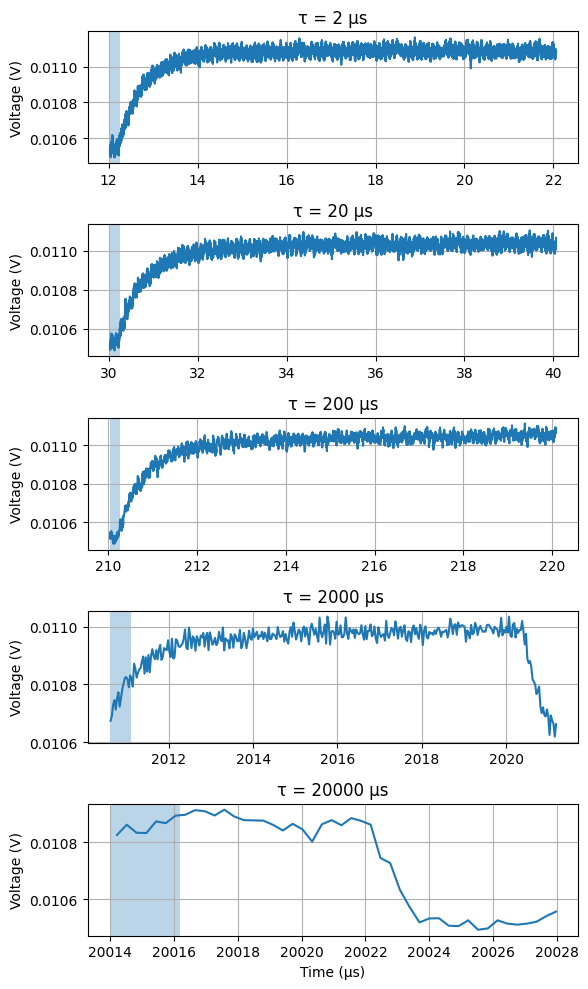

Ratios: [0.020844189061793746, 0.02092273817587092, 0.021201947910267954, 0.045373120966738616, 0.15991188320899719]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# dark times (µs)
list_darktime = [2, 20, 200, 2000, 20000]

# edge durations (seconds)
list_edge = [15e-9, 15e-9, 21e-9, 301e-9, 2e-6]

ratio_list = []

fig, ax = plt.subplots(len(list_darktime), 1, figsize=(6,10))


for i, t in enumerate(list_darktime):

    # load data
    df_read = pd.read_csv(f"D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau {t}us/averaged_waveform.csv")
    df_read.columns = ["Time","Voltage"]

    polarize_pulse_width = 10e-6
    dark_time = t * 1e-6
    edge = list_edge[i]

    # timing windows
    t0 = 2*edge + polarize_pulse_width + dark_time
    t1 = t0 + edge + 200e-9
    t2 = t1 + polarize_pulse_width - 200e-9 + edge

    # integration regions
    reading = df_read[(df_read["Time"] >= t0) & (df_read["Time"] < t1)]
    reference = df_read[(df_read["Time"] >= t1) & (df_read["Time"] < t2)]

    # integrate
    reading_int = np.trapz(reading["Voltage"], reading["Time"])
    reference_int = np.trapz(reference["Voltage"], reference["Time"])

    if reference_int != 0:
        ratio = reading_int / reference_int
    else:
        ratio = np.nan

    ratio_list.append(ratio)

    # plot only around the window
    margin = 0.3e-10
    window = df_read[(df_read["Time"] >= t0-margin) & (df_read["Time"] <= t2+margin)]

    ax[i].plot(window["Time"]*1e6, window["Voltage"], label="Waveform")

    # highlight integration regions
    ax[i].axvspan(t0*1e6, t1*1e6, alpha=0.3, label="Reading")
    # ax[i].axvspan(t1*1e6, t2*1e6, alpha=0.3, label="Reference")

    ax[i].set_title(f"τ = {t} µs")
    ax[i].set_ylabel("Voltage (V)")
    ax[i].grid(True)

ax[-1].set_xlabel("Time (µs)")

plt.tight_layout()
plt.show()

print("Ratios:", ratio_list)

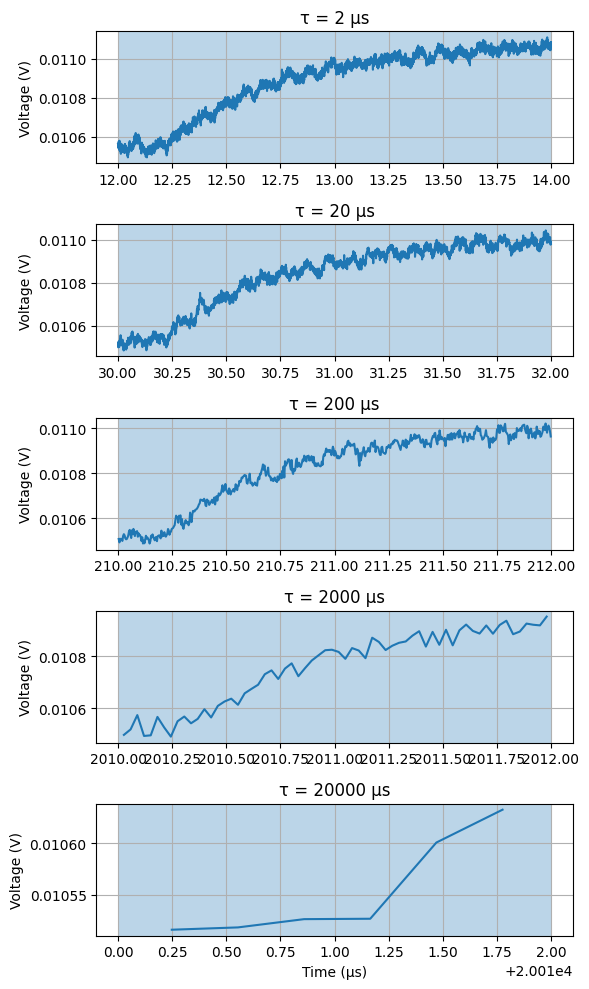

Ratios: [0.9819916096602183, 0.982885322711479, 0.9795136286017193, 0.9648643795483343, 0.8085141123331431]


In [ ]:
# NO EDGE 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# dark times (µs)
list_darktime = [2, 20, 200, 2000, 20000]

# edge durations (seconds)
list_edge = [15e-9, 15e-9, 21e-9, 301e-9, 2e-6]

ratio_list = []

fig, ax = plt.subplots(len(list_darktime), 1, figsize=(6,10))


for i, t in enumerate(list_darktime):

    # load data
    df_read = pd.read_csv(f"D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau {t}us/averaged_waveform.csv")
    df_read.columns = ["Time","Voltage"]

    polarize_pulse_width = 10e-6
    dark_time = t * 1e-6
    edge = list_edge[i]

    # timing windows
    t0 = polarize_pulse_width + dark_time
    t1 = t0 + 2000e-9
    t2 = polarize_pulse_width/2
    t3 = t2 + 2000e-9

    # integration regions
    reading = df_read[(df_read["Time"] >= t0) & (df_read["Time"] < t1)]
    reference = df_read[(df_read["Time"] >= t2) & (df_read["Time"] < t3)]

    # integrate
    reading_int = np.trapz(reading["Voltage"], reading["Time"])
    reference_int = np.trapz(reference["Voltage"], reference["Time"])

    if reference_int != 0:
        ratio = reading_int / reference_int
    else:
        ratio = np.nan

    ratio_list.append(ratio)

    # plot only around the window
    margin = 0.3e-10
    window = df_read[(df_read["Time"] >= t0-margin) & (df_read["Time"] <= t1+margin)]

    ax[i].plot(window["Time"]*1e6, window["Voltage"], label="Waveform")

    # highlight integration regions
    ax[i].axvspan(t0*1e6, t1*1e6, alpha=0.3, label="Reading")
    # ax[i].axvspan(t2*1e6, t3*1e6, alpha=0.3, label="Reference")

    ax[i].set_title(f"τ = {t} µs")
    ax[i].set_ylabel("Voltage (V)")
    ax[i].grid(True)

ax[-1].set_xlabel("Time (µs)")

plt.tight_layout()
plt.show()

print("Ratios:", ratio_list)

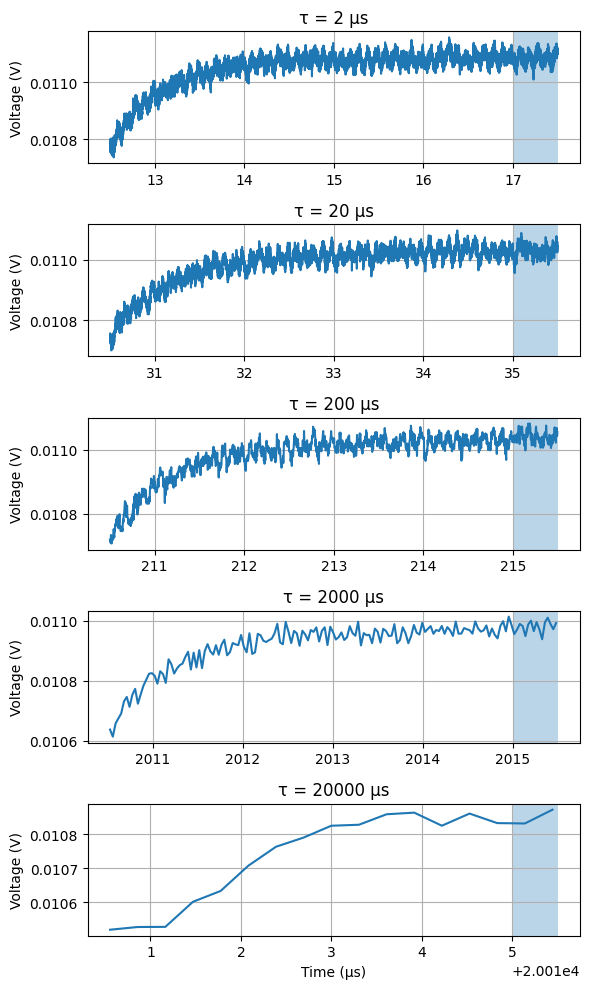

Ratios: [0.9577812024323971, 0.9610589910893476, 0.9586889111010796, 0.9606959251405212, 0.0]


In [ ]:
# NO EDGE 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# dark times (µs)
list_darktime = [2, 20, 200, 2000, 20000]

# edge durations (seconds)
list_edge = [15e-9, 15e-9, 21e-9, 301e-9, 2e-6]

ratio_list = []

fig, ax = plt.subplots(len(list_darktime), 1, figsize=(6,10))


for i, t in enumerate(list_darktime):

    # load data
    df_read = pd.read_csv(f"D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau {t}us/averaged_waveform.csv")
    df_read.columns = ["Time","Voltage"]

    polarize_pulse_width = 10e-6
    dark_time = t * 1e-6
    edge = list_edge[i]

    # timing windows
    t0 = polarize_pulse_width + dark_time
    t1 = t0 + 500e-9
    t2 = t1 + polarize_pulse_width/2 - 500e-9
    t3 = t2 + 500e-9

    # integration regions
    reading = df_read[(df_read["Time"] >= t0) & (df_read["Time"] < t1)]
    reference = df_read[(df_read["Time"] >= t2) & (df_read["Time"] < t3)]

    # integrate
    reading_int = np.trapz(reading["Voltage"], reading["Time"])
    reference_int = np.trapz(reference["Voltage"], reference["Time"])

    if reference_int != 0:
        ratio = reading_int / reference_int
    else:
        ratio = np.nan

    ratio_list.append(ratio)

    # plot only around the window
    margin = 0.3e-10
    window = df_read[(df_read["Time"] >= t1-margin) & (df_read["Time"] <= t3+margin)]

    ax[i].plot(window["Time"]*1e6, window["Voltage"], label="Waveform")

    # highlight integration regions
    # ax[i].axvspan(t0*1e6, t1*1e6, alpha=0.3, label="Reading")
    ax[i].axvspan(t2*1e6, t3*1e6, alpha=0.3, label="Reference")

    ax[i].set_title(f"τ = {t} µs")
    ax[i].set_ylabel("Voltage (V)")
    ax[i].grid(True)

ax[-1].set_xlabel("Time (µs)")

plt.tight_layout()
plt.show()

print("Ratios:", ratio_list)

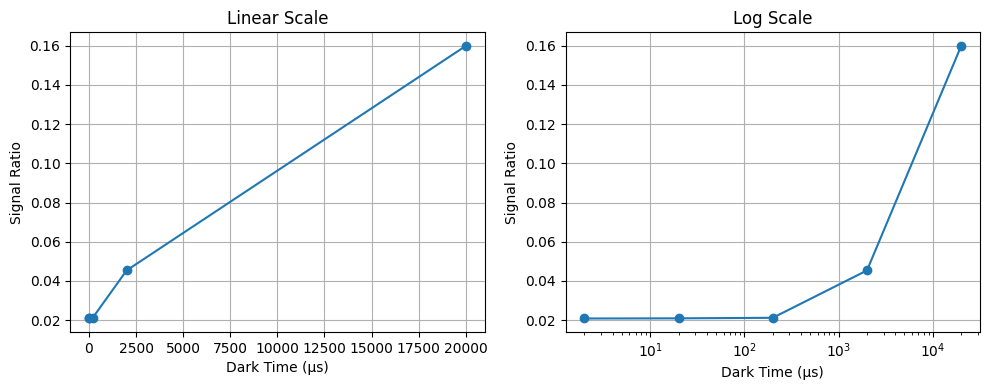

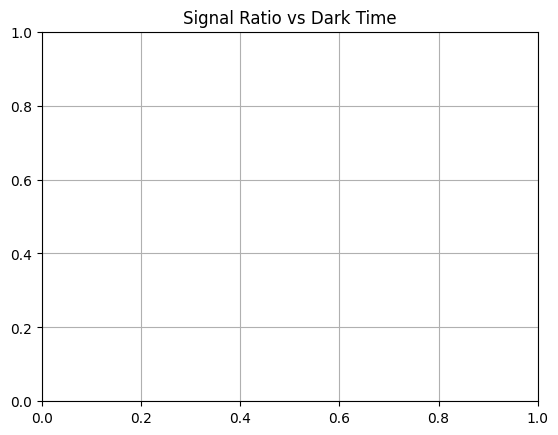

In [49]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10,4))

# Linear scale
ax[0].plot(list_darktime, ratio_list, marker='o')
ax[0].set_xlabel("Dark Time (µs)")
ax[0].set_ylabel("Signal Ratio")
ax[0].set_title("Linear Scale")
ax[0].grid(True)

# Log scale
ax[1].plot(list_darktime, ratio_list, marker='o')
ax[1].set_xscale("log")
ax[1].set_xlabel("Dark Time (µs)")
ax[1].set_ylabel("Signal Ratio")
ax[1].set_title("Log Scale")
ax[1].grid(True)

plt.tight_layout()
plt.show()
plt.title("Signal Ratio vs Dark Time")

plt.grid(True)

plt.show()

# 2 us

In [ ]:
import pandas as pd
import numpy as np

df_read = pd.read_csv(f"D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau 2us/averaged_waveform.csv")
df_read.columns = ["Time","Voltage"]

polarize_pulse_width = 10e-6
dark_time = t*1e-6
edge = 15e-9

t0 = edge + polarize_pulse_width + dark_time
t1 = t0 + 0.5*edge + 200e-9
t2 = t1 + polarize_pulse_width - 200e-9 + 0.5*edge

reading = df_read[(df_read["Time"] >= t0) & (df_read["Time"] < t1)]
# reference = df[(df["Time"] >= t1)]
reference = df_read[(df_read["Time"] >= t1) & (df_read["Time"] <t2) ]

reading_int = np.trapz(reading["Voltage"], reading["Time"])
reference_int = np.trapz(reference["Voltage"], reference["Time"])

ratio = reading_int / reference_int
print("Ratio:", ratio)

Ratio: nan


C:\Users\trina\AppData\Local\Temp\ipykernel_26856\2345779814.py:22: RuntimeWarning: invalid value encountered in scalar divide
  ratio = reading_int / reference_int


# 20 us

In [ ]:
import pandas as pd
import numpy as np

df_read = pd.read_csv("D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau 20us/averaged_waveform.csv")
df_read.columns = ["Time","Voltage"]

polarize_pulse_width = 10e-6
dark_time = 20e-6


t0 = polarize_pulse_width + dark_time
t1 = t0 + 200e-9

reading = df_read[(df_read["Time"] >= t0) & (df_read["Time"] < t1)]
reference = df_read[df_read["Time"] >= t1]

reading_int = np.trapz(reading["Voltage"], reading["Time"])
reference_int = np.trapz(reference["Voltage"], reference["Time"])

ratio = reading_int / reference_int

print("Ratio:", ratio)

Ratio: 0.004572662950133712


# 200 us

In [ ]:
import pandas as pd
import numpy as np

df_read = pd.read_csv("D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau 200us/averaged_waveform.csv")
df_read.columns = ["Time","Voltage"]

polarize_pulse_width = 10e-6
dark_time = 200e-6

t0 = polarize_pulse_width + dark_time
t1 = t0 + 200e-9

reading = df_read[(df_read["Time"] >= t0) & (df_read["Time"] < t1)]
reference = df_read[df_read["Time"] >= t1]

reading_int = np.trapz(reading["Voltage"], reading["Time"])
reference_int = np.trapz(reference["Voltage"], reference["Time"])

ratio = reading_int / reference_int

print("Ratio:", ratio)

Ratio: 0.0010006913128450927


# 2 ms

In [ ]:
import pandas as pd
import numpy as np

df_read = pd.read_csv("D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau 2000us/averaged_waveform.csv")
df_read.columns = ["Time","Voltage"]

polarize_pulse_width = 10e-6
dark_time = 2000e-6

t0 = polarize_pulse_width + dark_time
t1 = t0 + 200e-9

reading = df_read[(df_read["Time"] >= t0) & (df_read["Time"] < t1)]
reference = df_read[df_read["Time"] >= t1]

reading_int = np.trapz(reading["Voltage"], reading["Time"])
reference_int = np.trapz(reference["Voltage"], reference["Time"])

ratio = reading_int / reference_int

print("Ratio:", ratio)

Ratio: 9.154275264091266e-05


# 20 ms

In [ ]:
import pandas as pd
import numpy as np

df_read = pd.read_csv("D:/trina/TA_internal/2026-03-12/RT_Glass_5us/tau 20000us/averaged_waveform.csv")
df_read.columns = ["Time","Voltage"]

polarize_pulse_width = 10e-6
dark_time = 20000e-6

t0 = polarize_pulse_width + dark_time
t1 = t0 + 200e-9

reading = df_read[(df_read["Time"] >= t0) & (df_read["Time"] < t1)]
reference = df_read[df_read["Time"] >= t1]

reading_int = np.trapz(reading["Voltage"], reading["Time"])
reference_int = np.trapz(reference["Voltage"], reference["Time"])

ratio = reading_int / reference_int

print("Ratio:", ratio)

Ratio: 0.0


---

A = 31.181308521743603
B = -31.177980843447816
T1 = -171.4950260180974 seconds


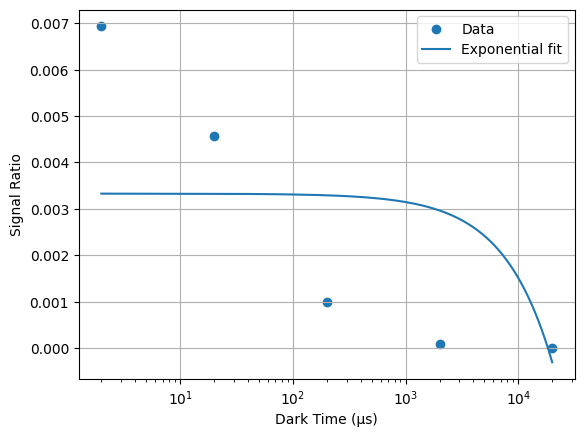

R(t) = 31.18131 + -31.17798 * exp(-t / -1.71495e+02)


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def exp_decay(t, A, B, T1):
    return A + B * np.exp(-t / T1)

x = np.array(list_darktime) * 1e-6   # convert µs → s
y = np.array(ratio_list)

params, _ = curve_fit(exp_decay, x, y)

A, B, T1 = params

print("A =", A)
print("B =", B)
print("T1 =", T1, "seconds")

x_fit = np.linspace(min(x), max(x), 500)
y_fit = exp_decay(x_fit, A, B, T1)

plt.figure()

plt.scatter(x*1e6, y, label="Data")
plt.plot(x_fit*1e6, y_fit, label="Exponential fit")

plt.xscale("log")

plt.xlabel("Dark Time (µs)")
plt.ylabel("Signal Ratio")

plt.legend()
plt.grid(True)

plt.show()

print(f"R(t) = {A:.5f} + {B:.5f} * exp(-t / {T1:.5e})")